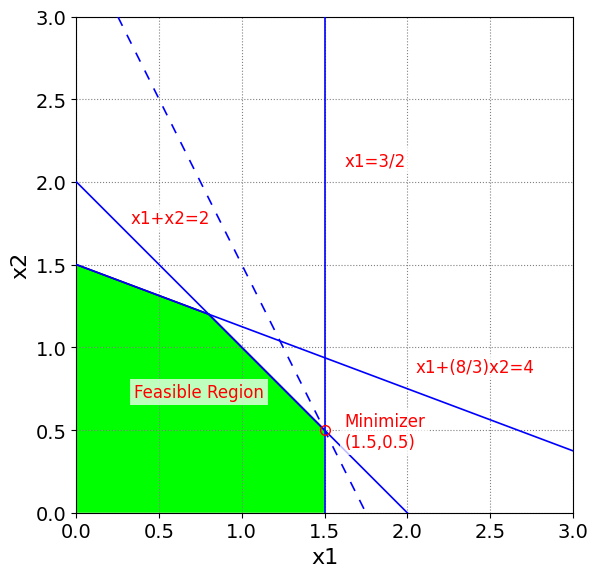

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,          # base font size (ticks, etc.)
    "axes.titlesize": 18,     # title
    "axes.labelsize": 16,     # x and y labels
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
    "legend.fontsize": 14     # legend
})

xmin, xmax = 0, 3
ymin, ymax = 0, 3

x = np.linspace(xmin, xmax, 600)

# Constraint boundary lines
y_x1_plus_x2 = 2 - x                
y_x1_plus_8over3x2 = 3*(4 - x)/8    

A = np.array([[1.0, 1.0],
              [1.0, 8.0/3.0]])
b = np.array([2.0, 4.0])
x_int, y_int = np.linalg.solve(A, b)   # (0.8, 1.2)

x1_max = 3/2

x_opt = x1_max
y_opt = 2 - x_opt                     

y_top = 3*(4 - 0)/8                  

# Feasible region polygon (in order)
V = np.array([
    [0.0,   0.0],
    [x1_max, 0.0],
    [x_opt, y_opt],
    [x_int, y_int],
    [0.0,   y_top]
])

f_opt = -2*x_opt - y_opt             
y_obj = -2*x - f_opt                 

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 6))

ax.fill(V[:, 0], V[:, 1], facecolor="lime", edgecolor="none", zorder=1)

ax.plot([0.0, x_int], [y_top, y_int], color="black", lw=1.2, zorder=2)
ax.plot([x_int, x_opt], [y_int, y_opt], color="black", lw=1.2, zorder=2)

ax.plot(x, y_x1_plus_x2, color="blue", lw=1.2, zorder=3)
ax.plot(x, y_x1_plus_8over3x2, color="blue", lw=1.2, zorder=3)
ax.axvline(x1_max, color="blue", lw=1.2, zorder=3)  # x1 = 3/2

ax.plot(x, y_obj, color="blue", lw=1.2, ls=(0, (6, 6)), zorder=3)
ax.plot(x_opt, y_opt, marker="o", markersize=7, markerfacecolor="none",
        markeredgecolor="red", zorder=5)
bbox = dict(boxstyle="square,pad=0.25", fc="white", ec="none", alpha=0.75)
ax.text(0.33, 1.75, "x1+x2=2", color="red", fontsize=12, bbox=bbox)
ax.text(1.62, 2.1,  "x1=3/2", color="red", fontsize=12, bbox=bbox)
ax.text(2.05, 0.85, "x1+(8/3)x2=4", color="red", fontsize=12, bbox=bbox)
ax.text(0.35, 0.70, "Feasible Region", color="red", fontsize=12, bbox=bbox)
ax.text(1.62, 0.40, "Minimizer\n(1.5,0.5)", color="red", fontsize=12, bbox=bbox)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xticks(np.arange(0, 3.1, 0.5))
ax.set_yticks(np.arange(0, 3.1, 0.5))
ax.grid(True, linestyle=":", color="0.5")
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


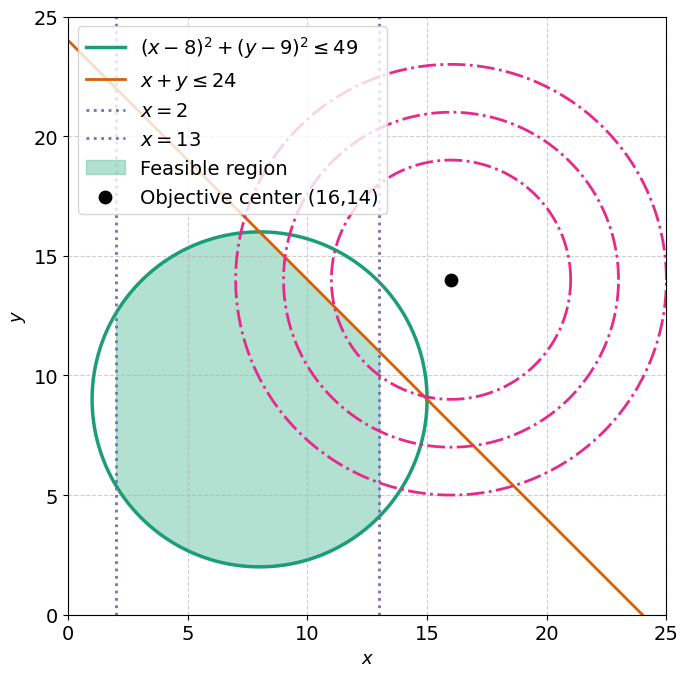

In [18]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.size": 14,          # base font size (ticks, etc.)
    "axes.titlesize": 18,     # title
    "axes.labelsize": 16,     # x and y labels
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
    "legend.fontsize": 14     # legend
})
# Objective center
a, b = 16, 14
radii = [5, 7, 9]  

x_fill = np.linspace(2, 13, 5000)

inside = 49 - (x_fill - 8)**2
y_low  = 9 - np.sqrt(np.clip(inside, 0, None))
y_high = 9 + np.sqrt(np.clip(inside, 0, None))

y_line = 24 - x_fill
y_top = np.minimum(y_high, y_line)

mask = (inside >= 0) & (y_top >= y_low)
t = np.linspace(0, 2*np.pi, 1500)

xc = 8 + 7*np.cos(t)
yc = 9 + 7*np.sin(t)

x_line = np.linspace(0, 25, 600)
y_line_plot = 24 - x_line

plt.figure(figsize=(9, 7))

plt.plot(xc, yc, color="#1b9e77", linewidth=2.5,
         label=r'$(x-8)^2+(y-9)^2\leq 49$')

plt.plot(x_line, y_line_plot, color="#d95f02", linewidth=2,
         label=r'$x+y\leq 24$')

plt.axvline(2, color="#7570b3", linestyle=":", linewidth=2,
            label=r'$x=2$')

plt.axvline(13, color="#7570b3", linestyle=":", linewidth=2,
            label=r'$x=13$')

plt.fill_between(
    x_fill, y_low, y_top,
    where=mask,
    color="#66c2a5",
    alpha=0.5,
    interpolate=True,
    label="Feasible region"
)

# Objective center
plt.scatter(a, b, color="black", s=80, marker="o", zorder=5,
            label=f'Objective center ({a},{b})')

# Objective contours
for r in radii:
    xo = a + r*np.cos(t)
    yo = b + r*np.sin(t)
    plt.plot(xo, yo, color="#e7298a",
             linestyle="-.", linewidth=2)

# Styling
# plt.title("Feasible Set & Level Curves", fontsize=14)
plt.xlabel(r"$x$", fontsize=13)
plt.ylabel(r"$y$", fontsize=13)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(0, 25)
plt.ylim(0, 25)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig("Example7_revised.png", dpi=600, bbox_inches="tight")
plt.show()
